In [3]:
import os
import time
#from obspy.io.segy.segy import _read_segy, SEGYBinaryFileHeader
from obspy import read
import numpy as np
import random
import gc
gc.collect()

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  

In [45]:
filename = '/home/zph/data/fault-detection/datasets/segy/item2_mig.sgy'
parent_dir = os.path.dirname(os.path.abspath(filename))
grandparent_dir = os.path.dirname(parent_dir)

# Read use _read_sgy()

In [ ]:
# t0=time.time()
# segy = _read_segy(filename)
# print('--> data read in {:.1f} sec'.format(time.time()-t0))

In [ ]:
# binary_file_header = segy.binary_file_header
# print("\nbinary_file_header:\n", binary_file_header)

# textual_file_header = segy.textual_file_header
# print("\ntextual_file_header:\n", textual_file_header)

# data_encoding=segy.data_encoding
# print("\ndata_encoding:\n",data_encoding)
# endian=segy.endian
# print("\nendian:\n", endian)
# file=segy.file
# print("\nfile:\n", file)
# classinfo = segy.__class__
# print("\nclassinfo:\n", classinfo)
# doc = segy.__doc__
# print("\ndoc:\n", doc)
# ntraces=len(segy.traces)
# print("\nntraces:\n", ntraces)
# size_M=segy.traces[0].data.nbytes/1024/1024.*ntraces
# print("\nsize:\n\t", size_M,"MB")
# print("\t", size_M/1024, "GB")

# Read use read()

In [46]:
t0=time.time()
print('sgy use read:')
stream = read(filename, format='SEGY',unpack_trace_headers=True)
print('--> data read in {:.1f} min'.format((time.time()-t0)/60))

sgy use read:


SEGYTraceReadingError: Too little data left in the file to unpack it according to
                  its trace header. This is most likely either due to a wrong
                  byte order or a corrupt file.

In [6]:
print(stream[0])

Seq. No. in line:    1 | 2009-01-01T00:00:00.000000Z - 2009-01-01T00:00:09.980000Z | 50.0 Hz, 500 samples


In [29]:
import pandas as pd
data = {}
k = 10000
for i in range(20):
    trace_header = stream[k * 10 + i].stats.segy.trace_header
    for key, value in trace_header.items():
        if isinstance(value, (int, float)) and value != 0:
            if key not in data:
                data[key] = []
            data[key].append(value)
df = pd.DataFrame(data)
df = df.transpose()
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
trace_sequence_number_within_line,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
trace_sequence_number_within_segy_file,100001,100002,100003,100004,100005,100006,100007,100008,100009,100010,100011,100012,100013,100014,100015,100016,100017,100018,100019,100020
trace_identification_code,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
number_of_vertically_summed_traces_yielding_this_trace,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
number_of_horizontally_stacked_traces_yielding_this_trace,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
data_use,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
receiver_group_elevation,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
source_depth_below_surface,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6
water_depth_at_group,764,766,765,765,765,764,764,766,767,767,767,768,769,771,772,772,773,774,774,775
scalar_to_be_applied_to_all_elevations_and_depths,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [9]:
il_name = 'for_3d_poststack_data_this_field_is_for_in_line_number'
xl_name = 'y_coordinate_of_ensemble_position_of_this_trace'
il=[]
xl=[]
for i in range(len(stream)):
    trace_i_header = stream[i].stats.segy.trace_header
    il.append(trace_i_header[il_name])
    xl.append(trace_i_header[xl_name])

In [10]:
inlines = np.unique(il)
print(inlines)
print(len(inlines))

[ 983  987  991  995  999 1003 1007 1011 1015 1019 1023 1027 1031 1035
 1036 1040 1044 1048 1052 1056 1060 1064 1068 1070 1074 1078 1082 1086
 1090 1094 1098 1102 1104 1108 1112 1116 1120 1124 1128 1132 1136 1138
 1142 1146 1150 1154 1158 1162 1166 1170 1172 1176 1180 1184 1188 1192
 1196 1200 1204 1206 1210 1214 1218 1222 1226 1230 1234 1238 1240 1244
 1248 1252 1256 1260 1264 1268 1272 1274 1278 1282 1286 1290 1294 1298
 1302 1306 1308 1312 1316 1320 1324 1328 1332 1336 1340 1342 1346 1350
 1354 1358 1362 1366 1370 1374 1376 1380 1384 1388 1392 1396 1400 1404
 1408 1410 1414 1418 1422 1426 1430 1434 1438 1442 1444 1448 1452 1456
 1460 1464 1468 1472 1476 1478 1482 1486 1490 1494 1498 1502 1506 1510
 1512 1516 1520 1524 1528 1532 1536 1540 1544 1546 1550 1554 1558 1562
 1566 1570 1574 1578 1580 1584 1588 1592 1596 1600 1604 1608 1612 1614
 1618 1622 1626 1630 1634 1638 1642 1646 1648 1652 1656 1660 1664 1668
 1672 1676 1680 1682 1686 1690 1694 1698 1702 1706 1710 1714 1716 1720
 1724 

In [11]:
xlines = np.unique(xl)
print(xlines)
print(len(xlines))

[ 504  510  516  522  528  534  540  546  552  558  564  570  576  582
  588  594  600  606  612  618  624  630  636  642  648  654  660  666
  672  678  684  690  696  702  708  714  720  726  732  738  744  750
  756  762  768  774  780  786  792  798  804  810  816  822  828  834
  840  846  852  858  864  870  876  882  888  894  900  906  912  918
  924  930  936  942  948  954  960  966  972  978  984  990  996 1002
 1008 1014 1020 1026 1032 1038 1044 1050 1056 1062 1068 1074 1080 1086
 1092 1098 1104 1110 1116 1122 1128 1134 1140 1146 1152 1158 1164 1170
 1176 1182 1188 1194 1200 1206 1212 1218 1224 1230 1236 1242 1248 1254
 1260 1266 1272 1278 1284 1290 1296 1302 1308 1314 1320 1326 1332 1338
 1344 1350 1356 1362 1368 1374 1380 1386 1392 1398 1404 1410 1416 1422
 1428 1434 1440 1446 1452 1458 1464 1470 1476 1482 1488 1494 1500 1506
 1512 1518 1524 1530 1536 1542 1548 1554 1560 1566 1572 1578 1584 1590
 1596 1602 1608 1614 1620 1626 1632 1638 1644 1650 1656 1662 1668 1674
 1680 

Check if the data is a cube shape

In [12]:
from collections import Counter
t0=time.time()
counter = Counter(il)
print('Count in {:.1f} sec'.format(time.time()-t0))
print (sorted(counter.items()))

Count in 0.1 sec
[(983, 843), (987, 843), (991, 843), (995, 843), (999, 843), (1003, 843), (1007, 843), (1011, 843), (1015, 843), (1019, 843), (1023, 843), (1027, 843), (1031, 843), (1035, 843), (1036, 843), (1040, 843), (1044, 843), (1048, 843), (1052, 843), (1056, 843), (1060, 843), (1064, 843), (1068, 843), (1070, 843), (1074, 843), (1078, 843), (1082, 843), (1086, 843), (1090, 843), (1094, 843), (1098, 843), (1102, 843), (1104, 843), (1108, 843), (1112, 843), (1116, 843), (1120, 843), (1124, 843), (1128, 843), (1132, 843), (1136, 843), (1138, 843), (1142, 843), (1146, 843), (1150, 843), (1154, 843), (1158, 843), (1162, 843), (1166, 843), (1170, 843), (1172, 843), (1176, 843), (1180, 843), (1184, 843), (1188, 843), (1192, 843), (1196, 843), (1200, 843), (1204, 843), (1206, 843), (1210, 843), (1214, 843), (1218, 843), (1222, 843), (1226, 843), (1230, 843), (1234, 843), (1238, 843), (1240, 843), (1244, 843), (1248, 843), (1252, 843), (1256, 843), (1260, 843), (1264, 843), (1268, 843),

In [13]:
from collections import Counter
t0=time.time()
counter = Counter(xl)
print('Count in {:.1f} sec'.format(time.time()-t0))
print (sorted(counter.items()))

Count in 0.1 sec
[(504, 909), (510, 909), (516, 909), (522, 909), (528, 909), (534, 909), (540, 909), (546, 909), (552, 909), (558, 909), (564, 909), (570, 909), (576, 909), (582, 909), (588, 909), (594, 909), (600, 909), (606, 909), (612, 909), (618, 909), (624, 909), (630, 909), (636, 909), (642, 909), (648, 909), (654, 909), (660, 909), (666, 909), (672, 909), (678, 909), (684, 909), (690, 909), (696, 909), (702, 909), (708, 909), (714, 909), (720, 909), (726, 909), (732, 909), (738, 909), (744, 909), (750, 909), (756, 909), (762, 909), (768, 909), (774, 909), (780, 909), (786, 909), (792, 909), (798, 909), (804, 909), (810, 909), (816, 909), (822, 909), (828, 909), (834, 909), (840, 909), (846, 909), (852, 909), (858, 909), (864, 909), (870, 909), (876, 909), (882, 909), (888, 909), (894, 909), (900, 909), (906, 909), (912, 909), (918, 909), (924, 909), (930, 909), (936, 909), (942, 909), (948, 909), (954, 909), (960, 909), (966, 909), (972, 909), (978, 909), (984, 909), (990, 909)

# this is a cube shape dataset.

In [14]:
del data,df,il,xl,counter
gc.collect()
seis_np = np.zeros((len(inlines),len(xlines),stream[0].stats.npts), dtype=np.float32)  # declare an empty array
print(seis_np.shape)

(909, 843, 500)


In [15]:
t0=time.time()
batch_size = 32
for i in range(0, len(stream), batch_size): # fill in the empty 3D array based on trace il number and crossline number.
    batch = stream[i:i + batch_size]
    for trace in batch:
        trace_il = trace.stats.segy.trace_header[il_name]
        trace_xl = trace.stats.segy.trace_header[xl_name]
        il_idx = int((trace_il - inlines[0]) / (inlines[1]-inlines[0]))
        xl_idx = int((trace_xl - xlines[0]) / (xlines[1]-xlines[0]))
        seis_np[il_idx][xl_idx] = trace.data # here 1001 is the initial inline number of the thebe dataset, will 851 is the initial crossline number
print('--> data read in {:.1f} min'.format((time.time()-t0)/60))

--> data read in 0.1 min


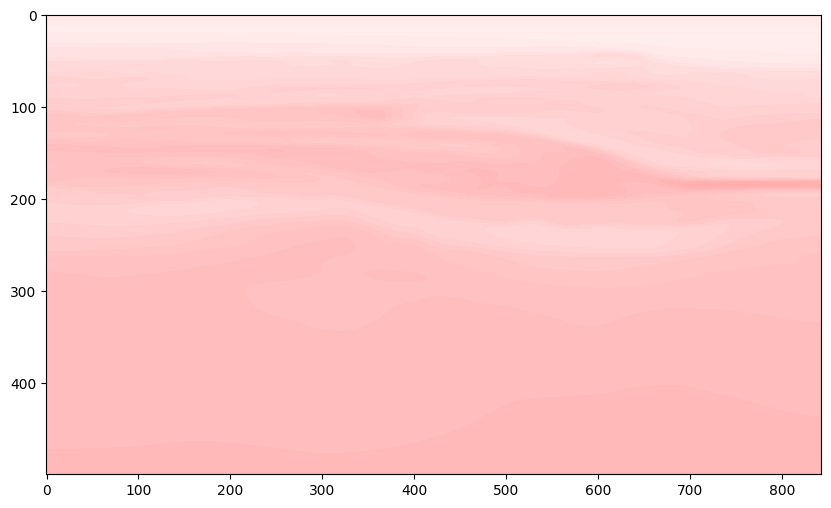

In [40]:
import matplotlib.pyplot as plt

vmax= np.max(np.abs(seis_np)) * 6
plt.figure(figsize=(10,10))
plt.imshow(seis_np[100,:,:].transpose(), "seismic", vmax=vmax, vmin=-vmax) 

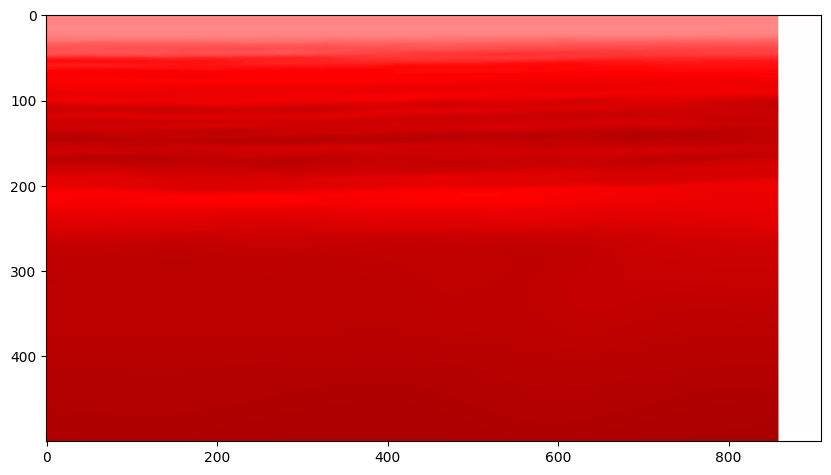

In [36]:
plt.figure(figsize=(10,10))
plt.imshow(seis_np[:,100,:].transpose(), "seismic",vmax=vmax, vmin=-vmax)

In [74]:
t0=time.time()
print('sgy save as npy:')
file_name = os.path.basename(filename)
new_file_name = os.path.splitext(file_name)[0] + '.npy'
np.save(new_file_name,seis_np)
print('--> data save in {:.1f} min'.format((time.time()-t0)/60))

sgy save as npy:
--> data save in 0.0 min


In [ ]:
t0=time.time()
print('npy spatial as block:')
seismic = np.load(parent_dir + '/' + new_file_name)
x1 = len(inlines)%128//2
x2 = len(inlines) - len(inlines)%128 + len(inlines)%128//2 - 1
y1 = len(xlines)%128//2
y2 = len(xlines) - len(xlines)%128 + len(xlines)%128//2 - 1
z1 = stream[0].stats.npts%128//2
z2 = stream[0].stats.npts - stream[0].stats.npts%128 + stream[0].stats.npts%128//2 - 1
seismic = seismic[x1:x2,y1:y2,z1:z2]
block_size = (128, 128, 128)
stride = (128, 128, 128)
blocks = []
for i in range(0, seismic.shape[0] - block_size[0] + 1, stride[0]):
    for j in range(0, seismic.shape[1] - block_size[1] + 1, stride[1]):
        for k in range(0, seismic.shape[2] - block_size[2] + 1, stride[2]):
            block = seismic[i:i+block_size[0], j:j+block_size[1], k:k+block_size[2]]
            blocks.append(block)
print('--> data spatial in {:.1f} min'.format((time.time()-t0)/60))

In [ ]:
t0=time.time()
os.mkdir(grandparent_dir + '/' + os.path.splitext(file_name)[0]) 
for idx, block in enumerate(blocks):
    file_path = f'{idx+1}.npy'
    file_path = os.path.join(grandparent_dir + '/' + os.path.splitext(file_name)[0], os.path.splitext(file_name)[0] + file_path)
    np.save(file_path, block)
print('--> data save in {:.1f} min'.format((time.time()-t0)/60))